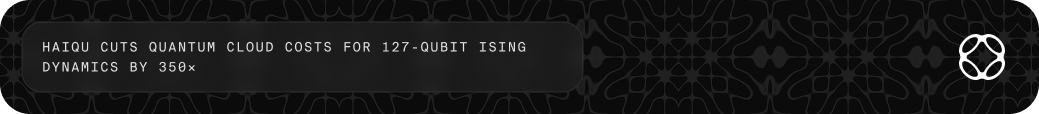

We simulate the dynamics of a **127-qubit transverse-field Ising model** on a real IBM Eagle processor and compare Haiqu's orchestration engine against IBM's error-mitigation pipeline. Both reach the same magnetisation curve, but Haiqu does it in **~41 seconds** at **~$33** versus IBM's **~4 hours** at **~$11,520** (350× faster, 350× cheaper). Original benchmark: [Kim et al., *Nature* **618**, 500 (2023)](https://www.nature.com/articles/s41586-023-06096-3).

> Note: QPU experiments were conducted on January 14th, 2026. Your mileage may vary

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the notebook

Import the necessary libraries, set the run mode and credentials, initialise the Haiqu SDK, load the device, and show the connectivity map.

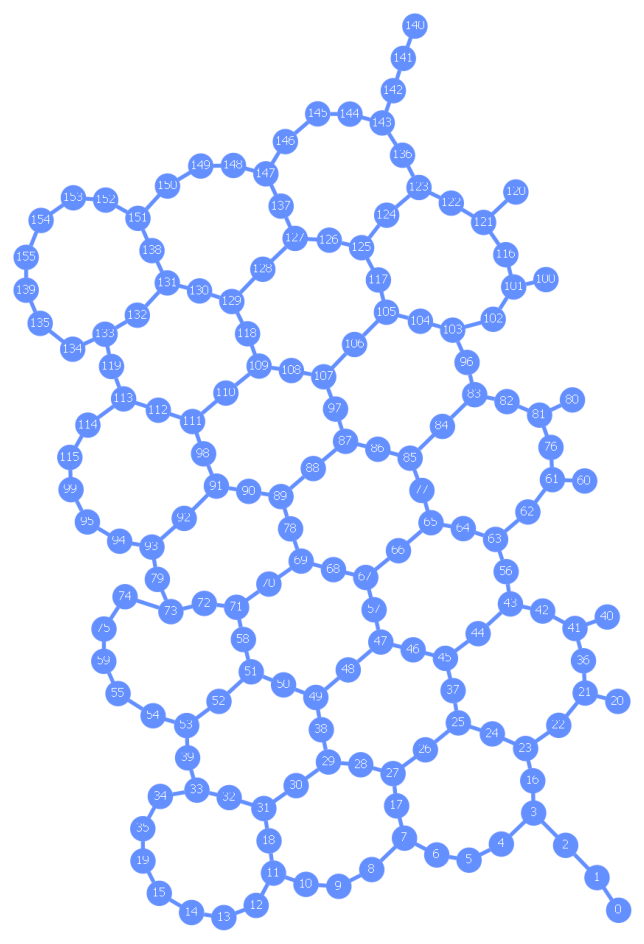

In [1]:
import json
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from haiqu.sdk import haiqu
from utils.standard_ising_utils import (
    make_ising_evolution_circuit, load_json_data,
    plot_magnetization, plot_performance, plot_pareto, show_device_connectivity,
)

# ── Configuration ──────────────────────────────────────────────
RUN_ON_DEVICE = False     # set True to actually submit and retrieve
DEVICE_ID = "ibm_boston"  # or "fake_marrakesh" for a free local simulator
OPTIONS = {               # set to {} when using a fake device
    "ibm_quantum_token":    "YOUR_IBM_QUANTUM_TOKEN",
    "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE",
}
N_QUBITS = 127

haiqu.login()
haiqu.init("Ising Simulation")

device = haiqu.get_device(DEVICE_ID)
show_device_connectivity(coupling_map=device.coupling_map, figsize=(12, 12))

## The model

The transverse-field Ising Hamiltonian

$$H = -J \sum_{\langle i,j \rangle} Z_i Z_j \;+\; h \sum_i X_i$$

couples neighbouring spins with strength $J$ under a transverse field of strength $h$. Because the two terms don't commute, $e^{-iHt}$ is approximated by a Trotterised product of $m = t/\Delta t$ steps. Sweeping $h$ from $0$ to $\pi/2$, we measure the average magnetisation $M = \tfrac{1}{N}\sum_i \langle Z_i \rangle$ — it falls from $1$ towards $0$ as the field randomises spin alignment along $\hat{z}$.

In [2]:
# Trotterised evolution circuit, parameterised by transverse field h
NUM_STEPS = 5
SHOTS = 10_000
TRANSVERSE_FIELDS = [[0.0], [0.1], [0.2], [0.3], [0.5], [0.7], [0.8],
                    [1.0], [1.2], [1.3], [1.4], [1.5], [1.5708]]

circuit = make_ising_evolution_circuit(
    num_qubits=N_QUBITS, num_steps=NUM_STEPS, backend_coupling_map=device.coupling_map,
)

# Observable: average single-site Z magnetisation, M = (1/N) sum_i <Z_i>
paulis = ["I" * i + "Z" + "I" * (N_QUBITS - i - 1) for i in range(N_QUBITS)]
magnetisation = SparsePauliOp(paulis, [1 / N_QUBITS] * N_QUBITS)
print(f"Built {N_QUBITS}-qubit circuit, sweeping {len(TRANSVERSE_FIELDS)} field values")

Built 127-qubit circuit, sweeping 13 field values


## Submit jobs to the QPU

We submit two runs of the circuit: one without error mitigation (**Noisy**) and one with Haiqu's mitigation engine (**Haiqu**). The job IDs are saved to disk so we can pick up the results later in a new session — QPU jobs can take minutes to hours to complete. Set `RUN_ON_DEVICE = True` to execute on real hardware (requires IBM Quantum credentials); otherwise the notebook will load cached results from a previous run further down.

In [3]:
JOB_IDS_FILE = "saved_job_ids.json"
LOAD_FROM_JOB = False  # set this to True if you wish to load results by fetching them from already executed jobs.

if RUN_ON_DEVICE:
    job_noisy = haiqu.run(
        circuit, parameters=TRANSVERSE_FIELDS, observables=[magnetisation],
        shots=SHOTS, device_id=DEVICE_ID, options=OPTIONS,
    )
    job_haiqu = haiqu.run(
        circuit, parameters=TRANSVERSE_FIELDS, observables=[magnetisation],
        shots=SHOTS, device_id=DEVICE_ID, options=OPTIONS, use_mitigation=True,
    )
    saved_job_ids = {"noisy": job_noisy.id, "haiqu": job_haiqu.id}
    with open(JOB_IDS_FILE, "w") as f:
        json.dump(saved_job_ids, f)
    print(f"Submitted: {saved_job_ids}")
    print(f"Job IDs saved to {JOB_IDS_FILE}")
else:
    print("Skipping live submission — cached results will be loaded next.")

Skipping live submission — cached results will be loaded next.


## Retrieve results

For live runs, we load the saved job IDs and call `haiqu.get_job(job_id).result()` — this works in a fresh notebook session too, so you can submit, walk away while the QPU runs, then come back later to retrieve. For the cached path we read JSON files from a previous run. Either way we end up with the same four magnetisation curves — **Ideal** (noise-free simulation), **Noisy** (raw QPU), **Baseline** (custom mitigation stack), **Haiqu** (ours) — plus runtime and cost for the two we submitted.

In [4]:
if RUN_ON_DEVICE or LOAD_FROM_JOB:
    with open(JOB_IDS_FILE) as f:
        saved_job_ids = json.load(f)
    job_noisy = haiqu.get_job(saved_job_ids["noisy"])
    job_haiqu = haiqu.get_job(saved_job_ids["haiqu"])
    noisy_results, noisy_qpu = job_noisy.result(), job_noisy.qpu_cost
    haiqu_results, haiqu_qpu = job_haiqu.result(), job_haiqu.qpu_cost
else:
    noisy_blob = load_json_data("cache/noisy.json")
    haiqu_blob = load_json_data("cache/haiqu.json")
    noisy_results, noisy_qpu = noisy_blob["results"], noisy_blob["qpu_cost"]
    haiqu_results, haiqu_qpu = haiqu_blob["results"], haiqu_blob["qpu_cost"]

noisy_mag, haiqu_mag = noisy_results[0][0], haiqu_results[0][0]
noisy_min, noisy_usd = noisy_qpu["native"]["amount"] / 60, noisy_qpu["converted"]["amount"]
haiqu_min, haiqu_usd = haiqu_qpu["native"]["amount"] / 60, haiqu_qpu["converted"]["amount"]

# Reference curves: noise-free simulation and IBM's published result (Kim et al., 2023)
ideal = load_json_data("cache/ideal.json")[0][0]
ibm   = load_json_data("cache/ibm.json")[0][0]
ibm_min, ibm_usd = 4 * 60, 4 * 60 * 48.0  # 4 hours on IBM Eagle at $48/min

> 💡 **Good to Know:** Average magnetisation decreases with increasing transverse field strength $h$ as spins are pushed towards $\hat{x}$ and randomised along the measurement axis $\hat{z}$. The solution obtained with Haiqu matches the one obtained by IBM. Both improve quality versus the noisy benchmark.

"Logged object to the experiment 'Ising Simulation'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

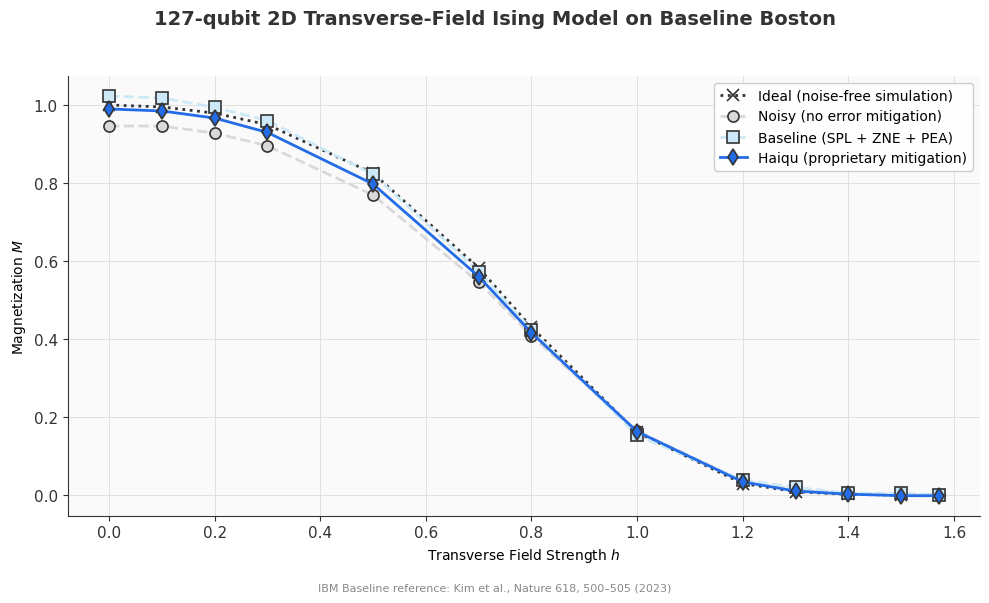

In [5]:
haiqu.log(
    plot_magnetization(
        transverse_field_params=TRANSVERSE_FIELDS,
        ideal_mag=ideal,
        noisy_mag=noisy_mag,
        ibm_mag=ibm,
        haiqu_mag=haiqu_mag,
    ),
    name="magnetisation",
)

> 💡 **Good to Know:** Haiqu's algorithmic and orchestration engine reduces the time to solution from 4h to 41s and the cost of solution from ~$10,000 to ~$30 compared to IBM's implementation. This is enabled through the use of proprietary lightweight, high-efficiency error mitigation algorithms and orchestration.

"Logged object to the experiment 'Ising Simulation'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

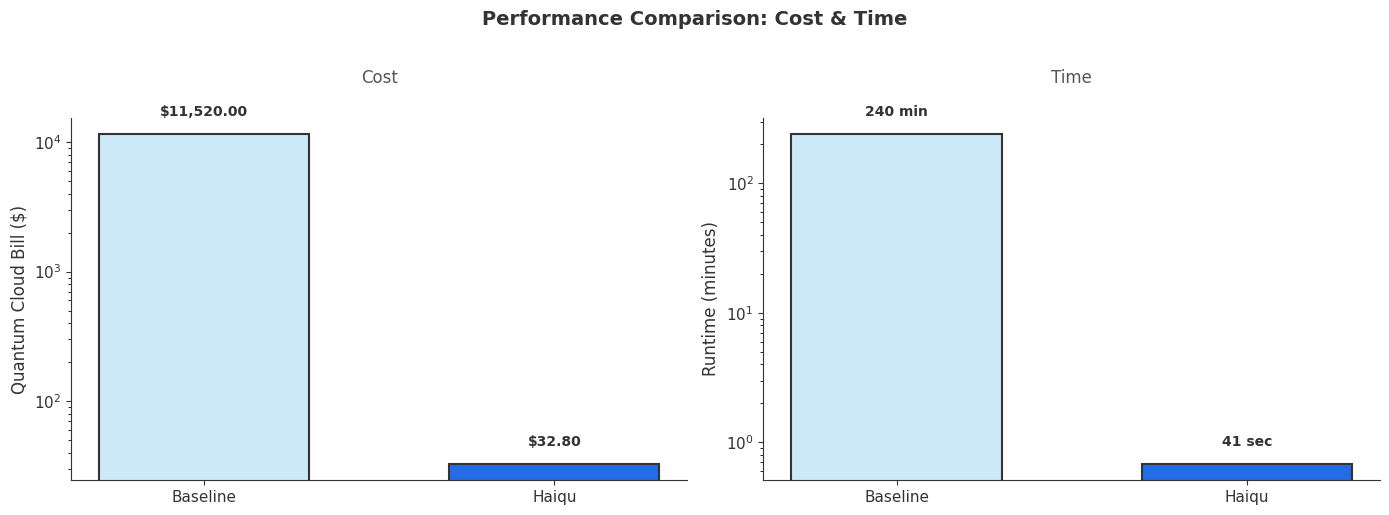

In [6]:
haiqu.log(
    plot_performance(
        labels=["Baseline", "Haiqu"],
        costs=[ibm_usd, haiqu_usd],
        times=[ibm_min, haiqu_min],
    ),
    name="performance",
)

"Logged object to the experiment 'Ising Simulation'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

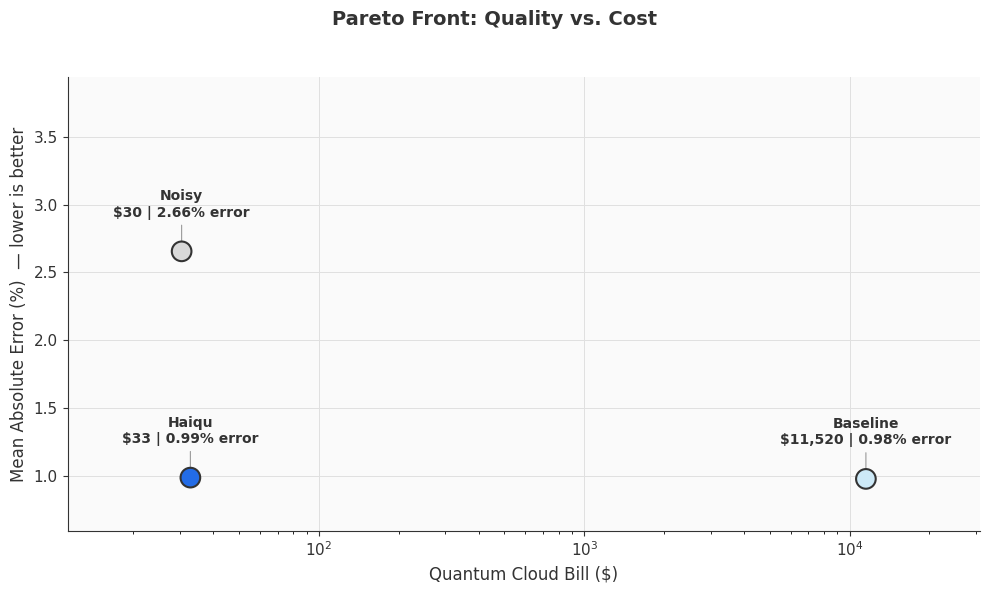

In [7]:
haiqu.log(
    plot_pareto(
        ideal_mag=ideal,
        scenario_names=["Noisy", "Baseline", "Haiqu"],
        scenario_costs=[noisy_usd, ibm_usd, haiqu_usd],
        scenario_mags=[noisy_mag, ibm, haiqu_mag],
    ),
    name="pareto",
)

## Conclusion

This notebook benchmarked Haiqu's orchestration engine against IBM's error mitigation pipeline on a **127-qubit 2D transverse-field Ising model** — a utility-scale quantum dynamics simulation that exceeds the reach of brute-force classical methods.

**Key findings:**

| Metric | IBM | Haiqu | Improvement |
|---|---|---|---|
| Quantum processor runtime | ~4 hours | ~41 seconds | **350x faster** |
| Quantum cloud bill | ~\$11,520 | ~\$33 | **350x cheaper** |
| Accuracy | Matches ideal | Matches ideal | Equivalent |

Haiqu achieves equivalent accuracy to IBM's Sparse Pauli-Lindblad + ZNE + PEA pipeline at **350x lower cost and time**, enabled by proprietary lightweight error mitigation and intelligent circuit orchestration. The Pareto plot above confirms that Haiqu occupies the optimal trade-off point — high quality at minimal cost.

**Reproducibility:** All results are cached under `cache/` and the notebook runs end-to-end in cached-results mode without QPU access. To reproduce on hardware, supply credentials in at the top of the notebook in the first code cell.

**Reference:** Kim et al., "Evidence for the utility of quantum computing before fault tolerance," *Nature* **618**, 500–505 (2023). [doi:10.1038/s41586-023-06096-3](https://doi.org/10.1038/s41586-023-06096-3)

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

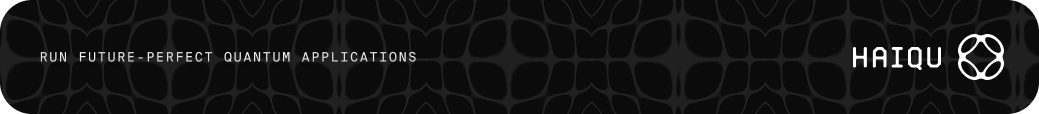